# Noise types TDV
```Authors: Paul Alvarez updated: 20261509```


El presente notebook explora diversos tipos de ruido aplicados en el proceso de $denoising$ de $\textbf{TDV}$. El algoritmo fue entrenado con imágenes del dataset BSDS400 degradas artificialmente mediante ruido guassiano ($\sigma = 25$). No obstante, en el campo del procesamiento de imágenes astronómicas el factor de ruido de las imágenes registradas viene modelado como una distribución Poisson, ya que implica el conteo discreto de los fotones registrados por sensores CCD. Por ello, el objetivo principal de este notebook es analizar el rendimiento de $\textbf{TDV}$ con la incportación de ruido ajeno al visto en el proceso de entrenamiento.


In [ ]:
import sys
import os
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path: sys.path.append(root_path)

In [ ]:
# requeriments
import imageio.v2 as imageio
import numpy as np
from tdv.denoise_utils import apply_vn, check_color, denoise_z, load_model, psnr, test_img
from skimage.metrics import structural_similarity as ssim
from notebooks.utils import plot_results
from skimage.util import random_noise

## Gaussian noise

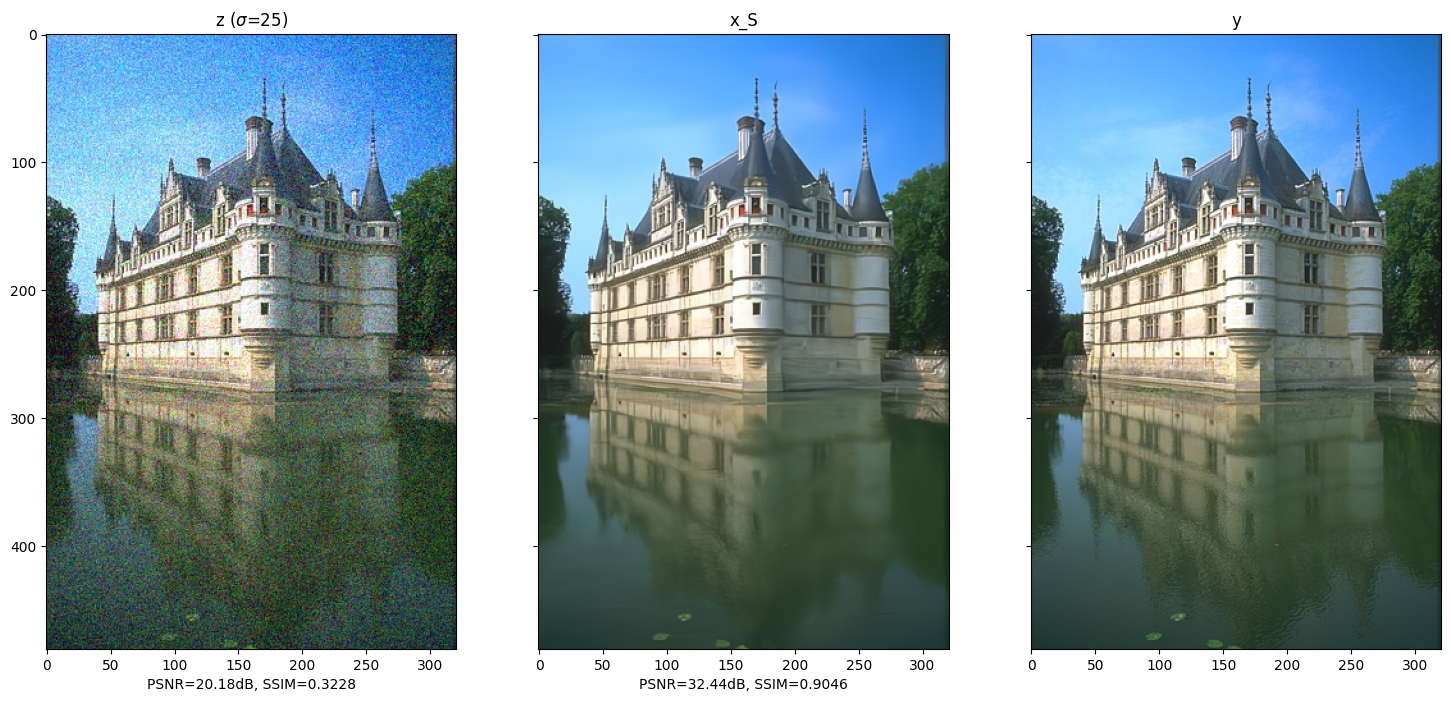

In [4]:
# Plot one img
vn_color, checkpoint = load_model("color")
img_path = os.path.join('..', 'data', 'water-castle.png')
img_01 = imageio.imread(img_path).astype(np.float32) / 255
z, x, y = test_img(vn_color, img_01, sigma= 25)
plot_results(z, x, y, sigma = 25)

## Poisson noise

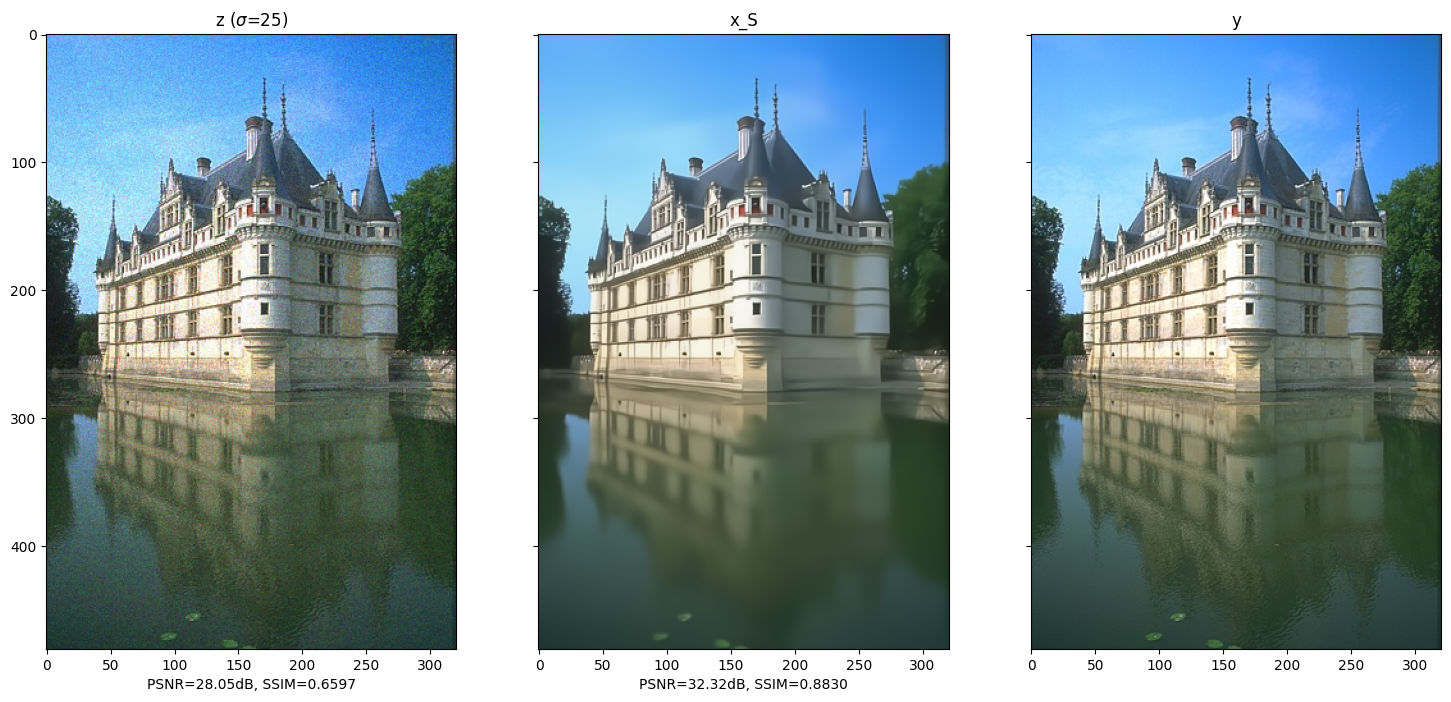

In [7]:
import imageio.v3 as iio

# Cargar imagen
y = img_01
z = random_noise(y, mode='poisson').astype(np.float32)
x_S = denoise_z(vn_color, z, sigma=25, sigma_ref=25, scaled=False)

# El resultado ya está normalizado entre 0.0 y 1.0 (tipo float)
plot_results(z, x_S, y, sigma=25, figsize= (18, 12))

## Salt and pepper

## Gaussian + Poisson